# GA-BO: Genetic Algorithm-Enhanced Bayesian Optimization with Diversity-Aware Acquisition

**Abstract**: We propose GA-BO, a novel Bayesian Optimization framework that integrates Genetic Algorithm (GA) as the acquisition function optimizer, coupled with a Diversity-Aware Expected Improvement (DA-EI) acquisition function. DA-EI explicitly balances exploitation via standard EI and exploration via a population diversity term with a time-decaying coefficient. Empirical evaluation on synthetic benchmarks and ML hyperparameter optimization demonstrates consistent improvements over standard BO, particularly in high-dimensional and mixed-variable spaces.



## 0. Environment Setup

In [9]:
# Install required packages (run once)
import subprocess, sys
packages = [
    'numpy', 'scipy', 'scikit-learn', 'matplotlib', 'seaborn',
    'pandas', 'GPy', 'deap', 'botorch', 'torch', 'gpytorch',
    'optuna', 'scikit-optimize', 'statsmodels', 'tqdm', 'joblib', 'ipywidgets'
]
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('All packages installed.')

All packages installed.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import time
import json
import os
from copy import deepcopy
from tqdm import tqdm
from joblib import Parallel, delayed
from dataclasses import dataclass, field
from typing import Callable, List, Tuple, Optional, Dict, Any

from scipy.stats import norm, wilcoxon, friedmanchisquare
from scipy.spatial.distance import cdist
from scipy.optimize import minimize

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    Matern, RBF, ConstantKernel, WhiteKernel
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
np.random.seed(42)

# Plotting style
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 150,
    'lines.linewidth': 2,
})

RESULTS_DIR = 'results'
FIGURES_DIR = 'figures'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print('Setup complete.')

Setup complete.


## 1. Benchmark Test Functions

In [3]:
@dataclass
class TestFunction:
    """Standard benchmark function container."""
    name: str
    func: Callable
    bounds: np.ndarray          # shape (d, 2)
    global_optimum: float
    dim: int
    optimal_x: Optional[np.ndarray] = None

    def __call__(self, x: np.ndarray) -> float:
        return self.func(x)


# ── Synthetic benchmark functions ──────────────────────────────────────────

def branin(x):
    """Branin-Hoo, d=2, global min ≈ 0.397887."""
    x1, x2 = x[0], x[1]
    a, b, c = 1, 5.1/(4*np.pi**2), 5/np.pi
    r, s, t = 6, 10, 1/(8*np.pi)
    return a*(x2 - b*x1**2 + c*x1 - r)**2 + s*(1-t)*np.cos(x1) + s

def rosenbrock(x):
    """Rosenbrock, d≥2, global min = 0 at (1,...,1)."""
    return sum(100*(x[i+1]-x[i]**2)**2 + (1-x[i])**2 for i in range(len(x)-1))

def ackley(x):
    """Ackley, d≥1, global min = 0 at origin."""
    d = len(x)
    a, b, c = 20, 0.2, 2*np.pi
    s1 = np.sum(x**2)
    s2 = np.sum(np.cos(c*x))
    return -a*np.exp(-b*np.sqrt(s1/d)) - np.exp(s2/d) + a + np.e

def rastrigin(x):
    """Rastrigin, d≥1, global min = 0 at origin."""
    d = len(x)
    return 10*d + np.sum(x**2 - 10*np.cos(2*np.pi*x))

def levy(x):
    """Levy, d≥1, global min = 0 at (1,...,1)."""
    w = 1 + (x - 1)/4
    t1 = np.sin(np.pi*w[0])**2
    t2 = np.sum((w[:-1]-1)**2 * (1 + 10*np.sin(np.pi*w[:-1]+1)**2))
    t3 = (w[-1]-1)**2 * (1 + np.sin(2*np.pi*w[-1])**2)
    return t1 + t2 + t3

def hartmann6(x):
    """Hartmann 6D, global min ≈ -3.32237."""
    alpha = np.array([1.0, 1.2, 3.0, 3.2])
    A = np.array([
        [10, 3, 17, 3.5, 1.7, 8],
        [0.05, 10, 17, 0.1, 8, 14],
        [3, 3.5, 1.7, 10, 17, 8],
        [17, 8, 0.05, 10, 0.1, 14]
    ])
    P = 1e-4 * np.array([
        [1312, 1696, 5569, 124, 8283, 5886],
        [2329, 4135, 8307, 3736, 1004, 9991],
        [2348, 1451, 3522, 2883, 3047, 6650],
        [4047, 8828, 8732, 5743, 1091, 381]
    ])
    return -np.sum(alpha * np.exp(-np.sum(A*(x - P)**2, axis=1)))

def schwefel(x):
    """Schwefel, d≥1, global min ≈ 0 at (420.9687,...)"""
    d = len(x)
    return 418.9829*d - np.sum(x * np.sin(np.sqrt(np.abs(x))))

def griewank(x):
    """Griewank, d≥1, global min = 0 at origin."""
    d = len(x)
    s = np.sum(x**2) / 4000
    p = np.prod(np.cos(x / np.sqrt(np.arange(1, d+1))))
    return s - p + 1


# ── Function registry ──────────────────────────────────────────────────────

BENCHMARK_FUNCTIONS = {
    'Branin': TestFunction(
        name='Branin', func=branin,
        bounds=np.array([[-5, 10], [0, 15]]),
        global_optimum=0.397887, dim=2,
        optimal_x=np.array([np.pi, 2.275])
    ),
    'Rosenbrock-4D': TestFunction(
        name='Rosenbrock-4D', func=rosenbrock,
        bounds=np.array([[-2, 2]]*4),
        global_optimum=0.0, dim=4,
        optimal_x=np.ones(4)
    ),
    'Ackley-5D': TestFunction(
        name='Ackley-5D', func=ackley,
        bounds=np.array([[-5, 5]]*5),
        global_optimum=0.0, dim=5,
        optimal_x=np.zeros(5)
    ),
    'Rastrigin-5D': TestFunction(
        name='Rastrigin-5D', func=rastrigin,
        bounds=np.array([[-5.12, 5.12]]*5),
        global_optimum=0.0, dim=5,
        optimal_x=np.zeros(5)
    ),
    'Levy-6D': TestFunction(
        name='Levy-6D', func=levy,
        bounds=np.array([[-10, 10]]*6),
        global_optimum=0.0, dim=6,
        optimal_x=np.ones(6)
    ),
    'Hartmann-6D': TestFunction(
        name='Hartmann-6D', func=hartmann6,
        bounds=np.array([[0, 1]]*6),
        global_optimum=-3.32237, dim=6,
        optimal_x=np.array([0.20169, 0.150011, 0.476874, 0.275332, 0.311652, 0.6573])
    ),
    'Ackley-10D': TestFunction(
        name='Ackley-10D', func=ackley,
        bounds=np.array([[-5, 5]]*10),
        global_optimum=0.0, dim=10,
        optimal_x=np.zeros(10)
    ),
    'Rastrigin-10D': TestFunction(
        name='Rastrigin-10D', func=rastrigin,
        bounds=np.array([[-5.12, 5.12]]*10),
        global_optimum=0.0, dim=10,
        optimal_x=np.zeros(10)
    ),
}

print(f'Registered {len(BENCHMARK_FUNCTIONS)} benchmark functions.')
for name, fn in BENCHMARK_FUNCTIONS.items():
    print(f'  {name:20s}  dim={fn.dim}  f*={fn.global_optimum:.4f}')

Registered 8 benchmark functions.
  Branin                dim=2  f*=0.3979
  Rosenbrock-4D         dim=4  f*=0.0000
  Ackley-5D             dim=5  f*=0.0000
  Rastrigin-5D          dim=5  f*=0.0000
  Levy-6D               dim=6  f*=0.0000
  Hartmann-6D           dim=6  f*=-3.3224
  Ackley-10D            dim=10  f*=0.0000
  Rastrigin-10D         dim=10  f*=0.0000


## 2. Gaussian Process Surrogate Model

In [4]:
class GPSurrogate:
    """
    Gaussian Process surrogate with automatic kernel selection,
    input normalization, and log-transform for positive targets.
    """

    def __init__(
        self,
        kernel_type: str = 'matern52',
        normalize_y: bool = True,
        n_restarts: int = 5,
        noise_level: float = 1e-6,
    ):
        self.kernel_type = kernel_type
        self.normalize_y = normalize_y
        self.n_restarts = n_restarts
        self.noise_level = noise_level
        self._build_kernel()
        self.scaler_X = StandardScaler()
        self.y_mean = 0.0
        self.y_std  = 1.0

    def _build_kernel(self):
        nu_map = {'matern52': 2.5, 'matern32': 1.5, 'matern12': 0.5}
        if self.kernel_type in nu_map:
            base = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
                length_scale=1.0,
                length_scale_bounds=(1e-2, 1e2),
                nu=nu_map[self.kernel_type]
            )
        else:  # RBF
            base = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(
                length_scale=1.0,
                length_scale_bounds=(1e-2, 1e2)
            )
        noise = WhiteKernel(noise_level=self.noise_level,
                            noise_level_bounds=(1e-10, 1e-3))
        self.gp = GaussianProcessRegressor(
            kernel=base + noise,
            n_restarts_optimizer=self.n_restarts,
            normalize_y=False,
            alpha=0.0
        )

    def fit(self, X: np.ndarray, y: np.ndarray):
        Xs = self.scaler_X.fit_transform(X)
        if self.normalize_y:
            self.y_mean = np.mean(y)
            self.y_std  = np.std(y) + 1e-8
            ys = (y - self.y_mean) / self.y_std
        else:
            ys = y
        self.gp.fit(Xs, ys)
        return self

    def predict(self, X: np.ndarray, return_std: bool = True):
        Xs = self.scaler_X.transform(X)
        mu, sigma = self.gp.predict(Xs, return_std=True)
        if self.normalize_y:
            mu    = mu    * self.y_std + self.y_mean
            sigma = sigma * self.y_std
        if return_std:
            return mu, sigma
        return mu

    def log_marginal_likelihood(self) -> float:
        return self.gp.log_marginal_likelihood_value_


# Quick smoke-test — runs automatically to verify GP is working
rng = np.random.RandomState(0)
X_test = rng.uniform(-2, 2, (30, 2))
y_test = np.array([branin(x) for x in X_test])
gp = GPSurrogate()
gp.fit(X_test, y_test)
mu, sigma = gp.predict(X_test[:5])
print('GP smoke-test: mu[:5] =', np.round(mu, 3))
print('LML =', round(gp.log_marginal_likelihood(), 3))

GP smoke-test: mu[:5] = [42.782 45.718 54.139 42.714 22.983]
LML = 63.823


## 3. Acquisition Functions

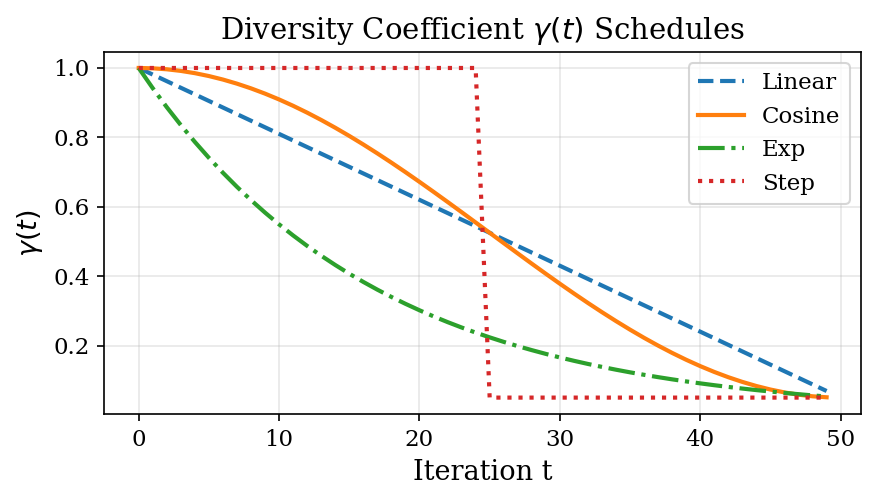

Figure saved.


In [5]:
# ── Standard EI ────────────────────────────────────────────────────────────

def expected_improvement(
    X: np.ndarray,
    gp: GPSurrogate,
    y_best: float,
    xi: float = 0.01
) -> np.ndarray:
    """
    Standard Expected Improvement.

    EI(x) = (y_best - mu(x) - xi) * Phi(Z) + sigma(x) * phi(Z)
    Z      = (y_best - mu(x) - xi) / sigma(x)

    Minimisation convention: improvement = y_best - mu(x) - xi.
    """
    X = np.atleast_2d(X)
    mu, sigma = gp.predict(X)
    sigma = np.maximum(sigma, 1e-9)
    improvement = y_best - mu - xi        # minimisation
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma < 1e-9] = 0.0
    return ei


# ── Diversity measure ───────────────────────────────────────────────────────

def diversity_score(
    X: np.ndarray,
    population: np.ndarray,
    metric: str = 'mean_min_dist'
) -> np.ndarray:
    """
    Quantifies how different each candidate in X is from the current population P_t.

    diversity(x | P_t) = mean over x of: min_{p in P_t} ||x - p||_2

    Variants:
      'min_dist'      — minimum distance to any member of population
      'mean_min_dist' — normalised mean of pairwise min distances (stable)
      'sum_dist'      — sum of distances (less sensitive to outliers)
    """
    X = np.atleast_2d(X)
    if population is None or len(population) == 0:
        return np.ones(len(X))

    D = cdist(X, population, metric='euclidean')  # (|X|, |P|)

    if metric == 'min_dist':
        scores = D.min(axis=1)
    elif metric == 'sum_dist':
        scores = D.sum(axis=1)
    else:  # mean_min_dist – default
        scores = D.min(axis=1)

    # Normalise to [0, 1]
    s_max = scores.max() + 1e-9
    return scores / s_max


# ── Diversity-Aware EI (DA-EI) ──────────────────────────────────────────────

def gamma_schedule(
    t: int,
    T: int,
    gamma_init: float = 1.0,
    gamma_final: float = 0.05,
    decay: str = 'cosine'
) -> float:
    """
    Time-decaying diversity coefficient γ(t).

    Schedules:
      'linear'  : γ(t) = γ_init · (1 - t/T) + γ_final · (t/T)
      'cosine'  : cosine annealing
      'exp'     : exponential decay
      'step'    : piecewise constant drop at T//2
    """
    progress = min(t / max(T, 1), 1.0)
    if decay == 'linear':
        return gamma_init * (1 - progress) + gamma_final * progress
    elif decay == 'cosine':
        return gamma_final + 0.5*(gamma_init - gamma_final)*(1 + np.cos(np.pi*progress))
    elif decay == 'exp':
        if gamma_init <= 0 or gamma_final <= 0:
            # Fallback to linear when boundary is zero (avoids log(0))
            return gamma_init * (1 - progress) + gamma_final * progress
        lam = -np.log(gamma_final / gamma_init)
        return gamma_init * np.exp(-lam * progress)
    elif decay == 'step':
        return gamma_init if t < T // 2 else gamma_final
    return gamma_init


def da_ei(
    X: np.ndarray,
    gp: GPSurrogate,
    y_best: float,
    population: np.ndarray,
    gamma: float,
    xi: float = 0.01,
    diversity_metric: str = 'mean_min_dist'
) -> np.ndarray:
    """
    Diversity-Aware Expected Improvement:

        DA-EI(x) = EI(x) + γ(t) · Diversity(x | P_t)

    Parameters
    ----------
    X              : candidate points  (N, d)
    gp             : fitted GP surrogate
    y_best         : best observed objective value so far
    population     : current evaluated population  (M, d)
    gamma          : diversity weight at current iteration t
    xi             : EI jitter
    diversity_metric: distance metric for diversity score

    Returns
    -------
    da_ei_vals : np.ndarray  (N,)
    """
    X = np.atleast_2d(X)
    ei_vals  = expected_improvement(X, gp, y_best, xi=xi)
    div_vals = diversity_score(X, population, metric=diversity_metric)

    # Normalise EI to [0,1] to make γ interpretable across functions
    ei_max = ei_vals.max() + 1e-9
    ei_norm = ei_vals / ei_max

    return ei_norm + gamma * div_vals


# ── Visualise γ schedules ───────────────────────────────────────────────────
T_plot = 50
t_arr  = np.arange(T_plot)
fig, ax = plt.subplots(figsize=(6, 3.5))
for dec, ls in [('linear','--'), ('cosine','-'), ('exp','-.'), ('step',':')]:
    gammas = [gamma_schedule(t, T_plot, decay=dec) for t in t_arr]
    ax.plot(t_arr, gammas, ls=ls, label=dec.capitalize())
ax.set_xlabel('Iteration t')
ax.set_ylabel(r'$\gamma(t)$')
ax.set_title(r'Diversity Coefficient $\gamma(t)$ Schedules')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/gamma_schedules.pdf', bbox_inches='tight')
plt.show()
print('Figure saved.')

## 4. GA/DE Acquisition Optimizer

In [6]:
class GAOptimizer:
    """
    Real-valued Genetic Algorithm for maximising an acquisition function.

    Key features
    ------------
    - Tournament selection
    - Simulated Binary Crossover (SBX)
    - Polynomial mutation
    - Warm-start from elite history
    - Adaptive population size  (large → small)
    - Elitism (top-k survival)
    """

    def __init__(
        self,
        bounds: np.ndarray,
        pop_size_init: int = 100,
        pop_size_final: int = 20,
        n_generations: int = 50,
        crossover_prob: float = 0.9,
        mutation_prob: Optional[float] = None,   # default 1/d
        eta_c: float = 20.0,                      # SBX distribution index
        eta_m: float = 20.0,                      # poly-mutation index
        tournament_size: int = 3,
        elitism_frac: float = 0.1,
        seed: int = 0,
    ):
        self.bounds         = bounds
        self.d              = bounds.shape[0]
        self.pop_size_init  = pop_size_init
        self.pop_size_final = pop_size_final
        self.n_generations  = n_generations
        self.crossover_prob = crossover_prob
        self.mutation_prob  = mutation_prob or 1.0/self.d
        self.eta_c          = eta_c
        self.eta_m          = eta_m
        self.tournament_size= tournament_size
        self.elitism_frac   = elitism_frac
        self.rng            = np.random.RandomState(seed)

    # ------------------------------------------------------------------
    # Helpers
    # ------------------------------------------------------------------

    def _clip(self, x):
        return np.clip(x, self.bounds[:, 0], self.bounds[:, 1])

    def _pop_size(self, gen: int) -> int:
        """Linearly decrease population size from init to final."""
        alpha = gen / max(self.n_generations - 1, 1)
        return max(int((1 - alpha)*self.pop_size_init + alpha*self.pop_size_final),
                   self.pop_size_final)

    def _init_population(self, warm_start: Optional[np.ndarray]) -> np.ndarray:
        N = self.pop_size_init
        # Latin Hypercube Sampling
        pop = self._lhs(N)
        if warm_start is not None and len(warm_start) > 0:
            n_warm = min(len(warm_start), N // 4)
            idx = np.argsort(self.rng.rand(len(warm_start)))[:n_warm]
            pop[:n_warm] = self._clip(warm_start[idx])
        return pop

    def _lhs(self, n: int) -> np.ndarray:
        """Latin Hypercube Sampling over bounds."""
        d = self.d
        cut = np.linspace(0, 1, n+1)
        samples = np.zeros((n, d))
        for j in range(d):
            u = self.rng.uniform(cut[:-1], cut[1:])
            self.rng.shuffle(u)
            samples[:, j] = u
        lo, hi = self.bounds[:, 0], self.bounds[:, 1]
        return lo + samples * (hi - lo)

    def _tournament_select(self, fitness: np.ndarray, k: int) -> np.ndarray:
        """Tournament selection — returns k winner indices."""
        winners = []
        for _ in range(k):
            participants = self.rng.choice(len(fitness), self.tournament_size, replace=False)
            winners.append(participants[np.argmax(fitness[participants])])
        return np.array(winners)

    def _sbx_crossover(self, p1: np.ndarray, p2: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """Simulated Binary Crossover (SBX)."""
        c1, c2 = p1.copy(), p2.copy()
        if self.rng.rand() > self.crossover_prob:
            return c1, c2
        for j in range(self.d):
            if self.rng.rand() > 0.5:
                continue
            if abs(p1[j] - p2[j]) < 1e-10:
                continue
            y1, y2 = min(p1[j], p2[j]), max(p1[j], p2[j])
            lo, hi = self.bounds[j, 0], self.bounds[j, 1]
            u = self.rng.rand()
            beta = 1 + 2*min(y1 - lo, hi - y2) / (y2 - y1)
            alpha = 2 - beta**(-(self.eta_c + 1))
            if u <= 1/alpha:
                betaq = (u * alpha)**(1/(self.eta_c+1))
            else:
                betaq = (1/(2 - u*alpha))**(1/(self.eta_c+1))
            c1[j] = np.clip(0.5*(y1+y2) - 0.5*betaq*(y2-y1), lo, hi)
            c2[j] = np.clip(0.5*(y1+y2) + 0.5*betaq*(y2-y1), lo, hi)
        return c1, c2

    def _poly_mutation(self, x: np.ndarray) -> np.ndarray:
        """Polynomial Mutation."""
        x = x.copy()
        for j in range(self.d):
            if self.rng.rand() > self.mutation_prob:
                continue
            lo, hi = self.bounds[j, 0], self.bounds[j, 1]
            delta = hi - lo
            if delta < 1e-10:
                continue
            u = self.rng.rand()
            if u < 0.5:
                delta_q = (2*u + (1-2*u)*(1 - (x[j]-lo)/delta)**(self.eta_m+1))**(1/(self.eta_m+1)) - 1
            else:
                delta_q = 1 - (2*(1-u) + 2*(u-0.5)*(1 - (hi-x[j])/delta)**(self.eta_m+1))**(1/(self.eta_m+1))
            x[j] = np.clip(x[j] + delta_q*delta, lo, hi)
        return x

    # ------------------------------------------------------------------
    # Main optimise
    # ------------------------------------------------------------------

    def optimise(
        self,
        acquisition_fn: Callable,
        warm_start: Optional[np.ndarray] = None,
        verbose: bool = False
    ) -> Tuple[np.ndarray, float]:
        """
        Maximise `acquisition_fn` over the search space.

        Parameters
        ----------
        acquisition_fn : callable (N, d) → (N,)  — higher is better
        warm_start     : seed candidates for initial population

        Returns
        -------
        x_best  : (d,)  best candidate
        f_best  : float best acquisition value
        """
        pop = self._init_population(warm_start)
        fitness = acquisition_fn(pop)

        best_idx = np.argmax(fitness)
        x_best, f_best = pop[best_idx].copy(), fitness[best_idx]

        for gen in range(self.n_generations):
            target_size = self._pop_size(gen)
            n_elite = max(1, int(self.elitism_frac * target_size))

            # Elite survival
            elite_idx = np.argsort(fitness)[::-1][:n_elite]
            elites = pop[elite_idx]

            # Offspring
            offspring = []
            n_offspring = target_size - n_elite
            parent_idx = self._tournament_select(fitness, n_offspring)
            for i in range(0, n_offspring - 1, 2):
                p1 = pop[parent_idx[i]]
                p2 = pop[parent_idx[i+1] if i+1 < n_offspring else parent_idx[0]]
                c1, c2 = self._sbx_crossover(p1, p2)
                offspring.extend([self._poly_mutation(c1),
                                   self._poly_mutation(c2)])
            if len(offspring) < n_offspring:
                offspring.append(self._poly_mutation(pop[parent_idx[-1]]))

            pop = np.vstack([elites, np.array(offspring[:n_offspring])])
            fitness = acquisition_fn(pop)

            idx = np.argmax(fitness)
            if fitness[idx] > f_best:
                x_best, f_best = pop[idx].copy(), fitness[idx]

            if verbose and (gen+1) % 10 == 0:
                print(f'  Gen {gen+1:3d}: best_acq={f_best:.6f}  pop_size={len(pop)}')

        return x_best, f_best


# ── Differential Evolution variant ─────────────────────────────────────────

class DEOptimizer:
    """
    Differential Evolution for acquisition function optimisation.
    Strategy: DE/rand/1/bin with adaptive F and CR.
    """

    def __init__(
        self,
        bounds: np.ndarray,
        pop_size: int = 50,
        n_generations: int = 100,
        F_init: float = 0.8,
        CR_init: float = 0.9,
        seed: int = 0,
    ):
        self.bounds = bounds
        self.d = bounds.shape[0]
        self.pop_size = pop_size
        self.n_generations = n_generations
        self.F = F_init
        self.CR = CR_init
        self.rng = np.random.RandomState(seed)

    def _init_pop(self, warm_start=None):
        lo, hi = self.bounds[:, 0], self.bounds[:, 1]
        pop = lo + self.rng.rand(self.pop_size, self.d) * (hi - lo)
        if warm_start is not None and len(warm_start) > 0:
            n = min(len(warm_start), self.pop_size // 4)
            pop[:n] = np.clip(warm_start[:n], lo, hi)
        return pop

    def optimise(
        self,
        acquisition_fn: Callable,
        warm_start: Optional[np.ndarray] = None,
        verbose: bool = False
    ) -> Tuple[np.ndarray, float]:
        lo, hi = self.bounds[:, 0], self.bounds[:, 1]
        pop     = self._init_pop(warm_start)
        fitness = acquisition_fn(pop)

        for gen in range(self.n_generations):
            # Adaptive F & CR (jDE strategy)
            F  = 0.1 + 0.9 * self.rng.rand() if self.rng.rand() < 0.1 else self.F
            CR = self.rng.rand()              if self.rng.rand() < 0.1 else self.CR

            # Build all trial vectors first, then batch-evaluate (faster)
            trials = np.empty_like(pop)
            for i in range(self.pop_size):
                idxs = [j for j in range(self.pop_size) if j != i]
                a, b, c = pop[self.rng.choice(idxs, 3, replace=False)]
                mutant = np.clip(a + F*(b - c), lo, hi)
                cross  = self.rng.rand(self.d) < CR
                if not cross.any():
                    cross[self.rng.randint(self.d)] = True
                trials[i] = np.where(cross, mutant, pop[i])
            # Batch acquisition evaluation
            f_trials = acquisition_fn(trials)
            for i in range(self.pop_size):
                if f_trials[i] > fitness[i]:
                    pop[i], fitness[i] = trials[i], f_trials[i]

        best = np.argmax(fitness)
        return pop[best], fitness[best]


print('GA and DE optimisers defined.')

GA and DE optimisers defined.


## 5. GA-BO Framework

In [7]:
@dataclass
class BOResult:
    """Container for a single BO run result."""
    method:        str
    func_name:     str
    best_values:   List[float]    # best-so-far at each iteration
    x_history:     np.ndarray     # evaluated points  (T, d)
    y_history:     np.ndarray     # evaluated values  (T,)
    diversity_hist:List[float]    # population diversity per iter
    wall_time:     float
    seed:          int

    @property
    def n_evals(self) -> int:
        return len(self.y_history)


class GABO:
    """
    GA-BO: Genetic Algorithm–Enhanced Bayesian Optimisation.

    Algorithm
    ---------
    1.  Initialise with n_init Latin-Hypercube samples.
    2.  For t = 1, …, T:
        a. Fit GP on (X_obs, y_obs).
        b. Compute γ(t) via chosen decay schedule.
        c. Define DA-EI with current population and γ.
        d. Use GA (or DE) to maximise DA-EI.
           Warm-start GA with elite observations from history.
        e. Evaluate x_next on black-box.
        f. Update dataset.
    3.  Return best (x*, f*).
    """

    def __init__(
        self,
        bounds: np.ndarray,
        n_init: int = 10,
        n_iter: int = 50,
        acq_type: str = 'da_ei',        # 'da_ei' | 'ei'
        optimizer_type: str = 'ga',     # 'ga' | 'de'
        gamma_init: float = 1.0,
        gamma_final: float = 0.05,
        gamma_decay: str = 'cosine',
        xi: float = 0.01,
        diversity_metric: str = 'mean_min_dist',
        kernel_type: str = 'matern52',
        # GA params
        ga_pop_init: int = 100,
        ga_pop_final: int = 20,
        ga_generations: int = 50,
        n_elite_warm: int = 5,
        seed: int = 42,
    ):
        self.bounds          = bounds
        self.d               = bounds.shape[0]
        self.n_init          = n_init
        self.n_iter          = n_iter
        self.acq_type        = acq_type
        self.optimizer_type  = optimizer_type
        self.gamma_init      = gamma_init
        self.gamma_final     = gamma_final
        self.gamma_decay     = gamma_decay
        self.xi              = xi
        self.diversity_metric= diversity_metric
        self.kernel_type     = kernel_type
        self.ga_pop_init     = ga_pop_init
        self.ga_pop_final    = ga_pop_final
        self.ga_generations  = ga_generations
        self.n_elite_warm    = n_elite_warm
        self.seed            = seed
        self.rng             = np.random.RandomState(seed)

    def _lhs_init(self) -> np.ndarray:
        d, n = self.d, self.n_init
        cut = np.linspace(0, 1, n+1)
        samples = np.zeros((n, d))
        for j in range(d):
            u = self.rng.uniform(cut[:-1], cut[1:])
            self.rng.shuffle(u)
            samples[:, j] = u
        lo, hi = self.bounds[:, 0], self.bounds[:, 1]
        return lo + samples * (hi - lo)

    def _build_optimizer(self, seed_offset: int = 0):
        if self.optimizer_type == 'de':
            return DEOptimizer(
                bounds=self.bounds,
                pop_size=self.ga_pop_init,
                n_generations=self.ga_generations,
                seed=self.seed + seed_offset
            )
        return GAOptimizer(
            bounds=self.bounds,
            pop_size_init=self.ga_pop_init,
            pop_size_final=self.ga_pop_final,
            n_generations=self.ga_generations,
            seed=self.seed + seed_offset
        )

    def run(
        self,
        objective: Callable,
        func_name: str = 'unknown',
        verbose: bool = False
    ) -> BOResult:

        t0 = time.time()

        # ── Initialisation ──────────────────────────────────────────────
        X_obs = self._lhs_init()
        y_obs = np.array([objective(x) for x in X_obs])

        best_values    = [y_obs.min()]
        diversity_hist = [0.0]

        # ── Main loop ───────────────────────────────────────────────────
        for t in range(self.n_iter):
            # (a) Fit GP
            gp = GPSurrogate(kernel_type=self.kernel_type)
            gp.fit(X_obs, y_obs)

            y_best = y_obs.min()

            # (b) Diversity coefficient
            gamma = gamma_schedule(
                t, self.n_iter,
                gamma_init=self.gamma_init,
                gamma_final=self.gamma_final,
                decay=self.gamma_decay
            )

            # (c) Acquisition function
            if self.acq_type == 'da_ei':
                acq_fn = lambda X: da_ei(
                    X, gp, y_best, X_obs, gamma,
                    xi=self.xi, diversity_metric=self.diversity_metric
                )
            else:  # plain EI
                acq_fn = lambda X: expected_improvement(X, gp, y_best, xi=self.xi)

            # (d) Warm-start from elite history
            elite_idx = np.argsort(y_obs)[:self.n_elite_warm]
            warm = X_obs[elite_idx]

            # Optimise
            opt = self._build_optimizer(seed_offset=t)
            x_next, _ = opt.optimise(acq_fn, warm_start=warm)

            # (e) Evaluate
            y_next = objective(x_next)

            # (f) Update
            X_obs = np.vstack([X_obs, x_next])
            y_obs = np.append(y_obs, y_next)

            best_values.append(y_obs.min())

            # Track diversity of observed population
            if len(X_obs) > 1:
                D = cdist(X_obs, X_obs, 'euclidean')
                np.fill_diagonal(D, np.inf)
                diversity_hist.append(D.min(axis=1).mean())
            else:
                diversity_hist.append(0.0)

            if verbose:
                print(f'  [t={t+1:3d}] y_best={y_obs.min():.6f}  '
                      f'y_new={y_next:.6f}  gamma={gamma:.3f}')

        return BOResult(
            method='GA-BO' if self.acq_type == 'da_ei' else 'BO-GA',
            func_name=func_name,
            best_values=best_values,
            x_history=X_obs,
            y_history=y_obs,
            diversity_hist=diversity_hist,
            wall_time=time.time() - t0,
            seed=self.seed
        )


print('GA-BO framework defined.')

GA-BO framework defined.


## 6. Baseline Methods

In [8]:
class StandardBO:
    """
    Vanilla Bayesian Optimisation:
    GP surrogate + EI + L-BFGS-B multi-start acquisition optimiser.
    """

    def __init__(
        self,
        bounds: np.ndarray,
        n_init: int = 10,
        n_iter: int = 50,
        n_restarts_acq: int = 20,
        xi: float = 0.01,
        kernel_type: str = 'matern52',
        seed: int = 42,
    ):
        self.bounds         = bounds
        self.d              = bounds.shape[0]
        self.n_init         = n_init
        self.n_iter         = n_iter
        self.n_restarts_acq = n_restarts_acq
        self.xi             = xi
        self.kernel_type    = kernel_type
        self.seed           = seed
        self.rng            = np.random.RandomState(seed)

    def _lhs_init(self):
        n, d = self.n_init, self.d
        cut  = np.linspace(0, 1, n+1)
        s    = np.zeros((n, d))
        for j in range(d):
            u = self.rng.uniform(cut[:-1], cut[1:])
            self.rng.shuffle(u)
            s[:, j] = u
        lo, hi = self.bounds[:, 0], self.bounds[:, 1]
        return lo + s*(hi - lo)

    def _optimise_acq(self, gp, y_best):
        lo, hi = self.bounds[:, 0], self.bounds[:, 1]
        scipy_bounds = list(zip(lo, hi))

        def neg_ei(x):
            return -expected_improvement(x.reshape(1, -1), gp, y_best, xi=self.xi)[0]

        x_best = lo + self.rng.rand(self.d) * (hi - lo)  # safe fallback
        f_best = np.inf
        x0s = lo + self.rng.rand(self.n_restarts_acq, self.d) * (hi - lo)
        for x0 in x0s:
            try:
                res = minimize(neg_ei, x0, method='L-BFGS-B', bounds=scipy_bounds,
                               options={'maxiter': 200})
                if res.fun < f_best:
                    x_best, f_best = res.x, res.fun
            except Exception:
                continue
        return x_best

    def run(self, objective, func_name='unknown', verbose=False) -> BOResult:
        t0 = time.time()
        X_obs = self._lhs_init()
        y_obs = np.array([objective(x) for x in X_obs])
        best_values    = [y_obs.min()]
        diversity_hist = [0.0]

        for t in range(self.n_iter):
            gp = GPSurrogate(kernel_type=self.kernel_type)
            gp.fit(X_obs, y_obs)
            x_next = self._optimise_acq(gp, y_obs.min())
            y_next = objective(x_next)
            X_obs  = np.vstack([X_obs, x_next])
            y_obs  = np.append(y_obs, y_next)
            best_values.append(y_obs.min())
            if len(X_obs) > 1:
                D = cdist(X_obs, X_obs, 'euclidean')
                np.fill_diagonal(D, np.inf)
                diversity_hist.append(D.min(axis=1).mean())
            else:
                diversity_hist.append(0.0)
            if verbose:
                print(f'  [t={t+1:3d}] y_best={y_obs.min():.6f}')

        return BOResult(
            method='Standard-BO', func_name=func_name,
            best_values=best_values, x_history=X_obs,
            y_history=y_obs, diversity_hist=diversity_hist,
            wall_time=time.time()-t0, seed=self.seed
        )


class RandomSearch:
    """Pure random search baseline."""

    def __init__(self, bounds, n_init=10, n_iter=50, seed=42):
        self.bounds = bounds
        self.d      = bounds.shape[0]
        self.n_init = n_init
        self.n_iter = n_iter
        self.seed   = seed
        self.rng    = np.random.RandomState(seed)

    def run(self, objective, func_name='unknown', verbose=False) -> BOResult:
        t0   = time.time()
        lo, hi = self.bounds[:, 0], self.bounds[:, 1]
        n_total = self.n_init + self.n_iter
        X_obs = lo + self.rng.rand(n_total, self.d) * (hi - lo)
        y_obs = np.array([objective(x) for x in X_obs])
        best_values = [np.min(y_obs[:i+1]) for i in range(n_total)]
        return BOResult(
            method='Random', func_name=func_name,
            best_values=best_values, x_history=X_obs,
            y_history=y_obs, diversity_hist=[0.0]*n_total,
            wall_time=time.time()-t0, seed=self.seed
        )


print('Baseline methods defined.')

Baseline methods defined.
